# Audio to UMAP

This notebook takes the audio-derived features from the previous step and uses them to generate a UMAP embedding.

For a more detailed explanation of the full workflow, refer to the notebook UMAP.ipynb and the official UMAP documentation.

## Libraries

In [26]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import umap
import umap.plot
from scipy.sparse import coo_matrix
from pathlib import Path


## Import CSV

In [3]:
df = pd.read_csv("assets/GSR_Analysis.csv")

df

,Count,Date,Time,Lat,Long,Speed,Altitude,GSR,normalised_gsr,time_audio,rms,centroid_hz,bandwidth_hz,flatness
0,0,27/5/2018,15:16:37,51.537693,-0.029900,4.70,0.0,565,0.999000,0.000000,315.740906,23.251970,271.015535,0.001086
1,1,27/5/2018,15:16:37,51.537693,-0.029900,4.70,67.6,563,0.960401,0.007317,427.908871,17.758700,217.282819,0.000791
2,2,27/5/2018,15:16:38,51.537708,-0.029881,3.11,67.6,563,0.960401,0.014634,540.076836,12.265430,163.550102,0.000495
3,3,27/5/2018,15:16:39,51.537716,-0.029865,3.22,67.6,559,0.881203,0.021951,652.244801,6.772161,109.817386,0.000200
4,4,27/5/2018,15:16:40,51.537689,-0.029866,6.67,67.6,557,0.841604,0.029268,623.832506,4.876862,75.718296,0.000110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4095,4095,27/5/2018,16:0:50,51.539581,-0.029403,4.39,11.3,515,0.010025,29.963415,1.792625,17.173945,32.507594,0.000004
4096,4096,27/5/2018,16:0:51,51.539570,-0.029411,4.39,11.3,512,-0.049373,29.970732,1.316321,20.539410,37.487742,0.000007
4097,4097,27/5/2018,16:0:51,51.539570,-0.029411,4.39,11.4,516,0.029825,29.976961,0.910797,23.404762,41.727832,0.000010
4098,4098,27/5/2018,16:0:52,51.539562,-0.029414,2.83,11.4,510,-0.088972,29.976961,0.910797,23.404762,41.727832,0.000010


## Normalise data

In [4]:
# Select numerical features for analysis and convert to NumPy array for processing with scikit-learn
selected_data = df[
    [
        "GSR",
        "rms",
        "centroid_hz",
        "bandwidth_hz",
        "flatness",
    ]
].values

# Scale features so that each column contributes comparably to distance calculations
scaled_selected_data = StandardScaler().fit_transform(selected_data)

print("Scaled data shape:", scaled_selected_data.shape)
scaled_selected_data[:5]

Scaled data shape: (4100, 5)


array([[ 3.59256842,  2.11462069,  2.2166698 , 27.0201156 , 47.90573009],
       [ 3.45030635,  3.12956115,  1.50979336, 21.45721775, 34.86716062],
       [ 3.45030635,  4.14450162,  0.80291692, 15.89431991, 21.82859115],
       [ 3.1657822 ,  5.15944208,  0.09604048, 10.33142207,  8.79002167],
       [ 3.02352013,  4.90235631, -0.14784746,  6.80117525,  4.8205261 ]])

## 2D UMAP

In [6]:
# Choose embedding dimension: 2 or 3
dim = 2  # change to 3 for 3D

# 1) Create the UMAP reducer (set parameters here)
reducer2D = umap.UMAP(
    n_components=dim,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)

# 2) FIT: learn the neighbour graph + embedding model from the training data
reducer2D.fit(scaled_selected_data)

# 3) TRANSFORM: generate embedding coordinates
embedding2D = reducer2D.transform(scaled_selected_data)

c:\Users\VincentNowak\AppData\Local\Programs\Python\Python314\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


## 3D UMAP

In [7]:
# Choose embedding dimension: 2 or 3
dim3 = 3  # change to 3 for 3D

# 1) Create the UMAP reducer (set parameters here)
reducer3D = umap.UMAP(
    n_components=dim3,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)

# 2) FIT: learn the neighbour graph + embedding model from the training data
reducer3D.fit(scaled_selected_data)

# 3) TRANSFORM: generate embedding coordinates
embedding3D = reducer3D.transform(scaled_selected_data)

c:\Users\VincentNowak\AppData\Local\Programs\Python\Python314\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


## Visuals
### 2D 

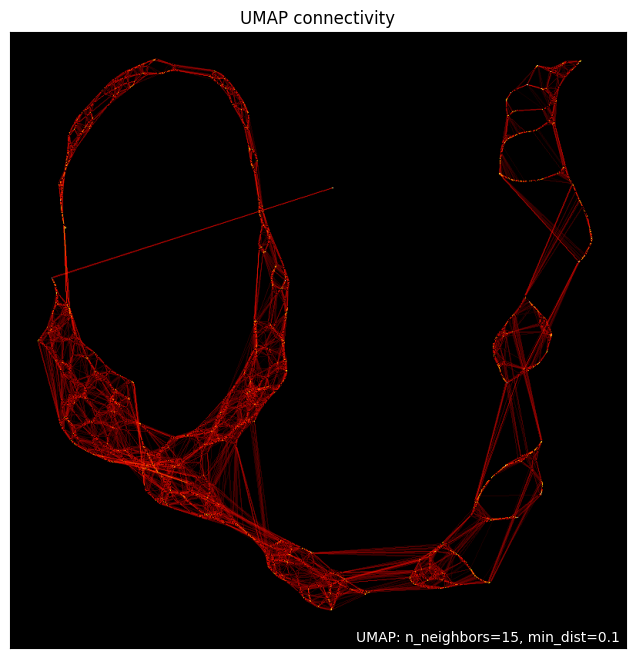

In [19]:
embedding2D = reducer2D.fit(scaled_selected_data)


umap.plot.connectivity(embedding2D, show_points=True,theme="fire")
plt.title("UMAP connectivity")
plt.show()



### 3D

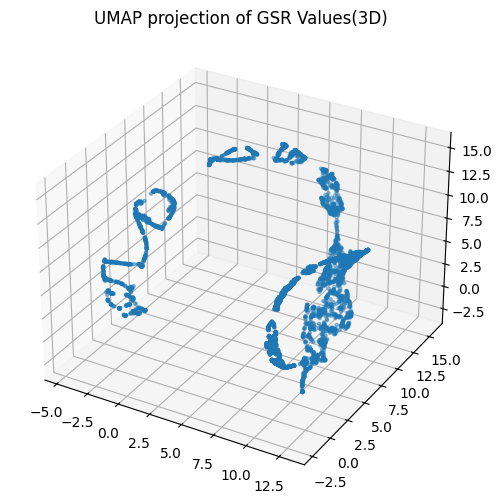

In [18]:
# Simple 3D plot (matplotlib)
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(embedding3D[:, 0], embedding3D[:, 1], embedding3D[:, 2], s=5)
ax.set_title("UMAP projection of GSR Values(3D)")
plt.show()

## Export

We extend the original data table by adding the two-dimensional and three-dimensional UMAP coordinates, as well as the connectivity information in a separate dataset.



In [31]:
df_extended = df.copy()

# embedding2D = reducer2D.fit_transform(scaled_selected_data)
# embedding3D = reducer3D.fit_transform(scaled_selected_data)

df_extended["2D_x"] = embedding2D[:, 0]
df_extended["2D_y"] = embedding2D[:, 1]
df_extended["3D_x"] = embedding3D[:, 0]
df_extended["3D_y"] = embedding3D[:, 1]
df_extended["3D_z"] = embedding3D[:, 2]

# Extract connectivity edges from 2D reducer
graph_2d = coo_matrix(reducer2D.graph_)
edges_2d = []

df_extended.head()

OUT_PATH = Path("assets/GSR_UMAP.csv")
df_extended.to_csv(OUT_PATH, index=False)

print("Saved:", OUT_PATH)

Saved: assets\GSR_UMAP.csv


In [32]:
# Extract connectivity edges from 2D reducer
graph_2d = coo_matrix(reducer2D.graph_)
edges_2d = []

for i, j, v in zip(graph_2d.row, graph_2d.col, graph_2d.data):
    edges_2d.append({
        "source_idx": i,
        "target_idx": j,
        "source_x": embedding2D[i, 0],
        "source_y": embedding2D[i, 1],
        "target_x": embedding2D[j, 0],
        "target_y": embedding2D[j, 1],
        "weight": v
    })

edges_2d_df = pd.DataFrame(edges_2d)
edges_2d_path =r"assets\umap_connectivity_2d.csv"
edges_2d_df.to_csv(edges_2d_path, index=False)
print(f"Wrote {len(edges_2d_df)} edges to: {edges_2d_path}")

# Extract connectivity edges from 3D reducer
graph_3d = coo_matrix(reducer3D.graph_)
edges_3d = []

for i, j, v in zip(graph_3d.row, graph_3d.col, graph_3d.data):
    edges_3d.append({
        "source_idx": i,
        "target_idx": j,
        "source_x": embedding3D[i, 0],
        "source_y": embedding3D[i, 1],
        "source_z": embedding3D[i, 2],
        "target_x": embedding3D[j, 0],
        "target_y": embedding3D[j, 1],
        "target_z": embedding3D[j, 2],
        "weight": v
    })

edges_3d_df = pd.DataFrame(edges_3d)
edges_3d_path = r"assets\umap_connectivity_3d.csv"
edges_3d_df.to_csv(edges_3d_path, index=False)
print(f"Wrote {len(edges_3d_df)} edges to: {edges_3d_path}")


Wrote 71306 edges to: assets\umap_connectivity_2d.csv
Wrote 71306 edges to: assets\umap_connectivity_3d.csv


## Summary - what have we got now?!

The result of our efforts is three tables: one containing the point coordinates, and two describing connectivity lines — one in 2D and the other in 3D.

Let’s focus on the main table. We took great care to keep the original information while feeding it with additional data. For example, we kept the original GSR coordinate readings, but we also recorded the geographic location where each reading was taken.

This means that the otherwise abstract UMAP point in space can now be directly linked to a specific position in the real world — and to a very specific GSR value.

Keep in mind that this is based on a single GSR reading. The more data points you have, the more meaningful and interesting the results become. You can now link it to images and video. 